In [2]:
from classes import *

In [3]:
from collections import Counter, defaultdict
import random

In [4]:
corpus = Corpus(
    filepath          = f'corpora/recipes',
    spell_correct     = 'corpora/spelling_dictionary',
    lemmatize         = False,
    removal_threshold = 1)

vectorizer = corpus.create_vectorizer(removal_threshold = 2)

Data collected:
    - 4107 unique words found.
    - most common words: ['\n', '-', '.', '1', ',']
    - least common words: ['www', 'yet', 'zinfandel', 'zip', 'zipper']


Corpus loaded:
    - 5000 sentences.
    - longest sentence: 

<START> whole wheat yeast bread 
 
 ingredients : 
 - 1 cup ( 2 2 5 ml ) scalded milk 
 - 1 / 4 cup ( 6 0 ml ) lard 
 - 4 tsp ( 2 0 ml ) . salt 
 - 1 / 4 cup ( 6 0 ml ) honey 
 - 1 cup ( 2 2 5 ml ) water , 1 1 0 - 1 1 5 degrees 
 - 2 pkg . dry yeast 
 - 2 tbsp ( 3 0 ml ) . brown sugar 
 - 2 cups ( 4 7 5 ml ) whole wheat flour 
 - 3 cups ( 7 0 0 ml ) or more white flour 
 
 directions : 
 - mix scalded milk , lard , salt & honey and let cool to lukewarm - about 8 5 degrees ( 3 0 c . ) . 
 - mix water , yeast & brown sugar and let stand to dissolve for 2 - 3 minutes . 
 - add yeast mixture to milk mixture . 
 - add whole wheat flour and enough white flour to make dough . 
 - mix well . 
 - knead 5 - 1 0 minutes . 
 - put in bowl to rise until double in size

In [6]:
word_pairs = []

for sentence in corpus.sentences:
    word_pairs.extend(zip(sentence[:-1], sentence[1:]))

pair_counts = dict(Counter(word_pairs))

count_counts = defaultdict(dict)

for pair in pair_counts:
    count_counts[pair[1]][pair[0]] = pair_counts[pair]

count_counts = {pair: sort_hl({key : count / corpus.word_counts[key] for key, count in counts.items()}) for pair, counts in count_counts.items()}

In [7]:
idx = random.randint(0, len(corpus.vocab))
print(list(count_counts.keys())[idx], count_counts[list(count_counts.keys())[idx]])

shallots {'crispy': 0.045454545454545456, 'bunches': 0.043478260869565216, 'med': 0.02, 'mince': 0.0196078431372549, 'none': 0.011627906976744186, 'fried': 0.008547008547008548, 'saute': 0.005494505494505495, 'minced': 0.005454545454545455, '&': 0.0030211480362537764, 'sliced': 0.0021119324181626186, 'x': 0.0013812154696132596, 'remaining': 0.001349527665317139, 'fresh': 0.0010050251256281408, 'the': 0.0009487666034155598, '<UNK>': 0.0008988764044943821, 'tablespoons': 0.0007668711656441718, 'chopped': 0.0007249003262051468, 'combine': 0.000722543352601156, 'medium': 0.0007220216606498195, 'cook': 0.0006253908692933083, 'cups': 0.0005704506560182544, '6': 0.0005691519635742744, 'add': 0.0004585052728106373, 'until': 0.00025233409033560434, 'and': 0.00018883363756530498, ')': 0.00018542555164101615, '2': 0.00017028039505051653, ',': 0.00014612050070624908, 'in': 0.0001178967224711153, '.': 2.1610407572286814e-05, '-': 1.4569189078935867e-05}


In [8]:
counts = count_counts[list(count_counts.keys())[idx]]
scaled_CRVs = {key: vectorizer.to_CRV(key) / val for key, val in counts.items()}

In [11]:
average_crv = vectorizer.average(*list(scaled_CRVs.values()))

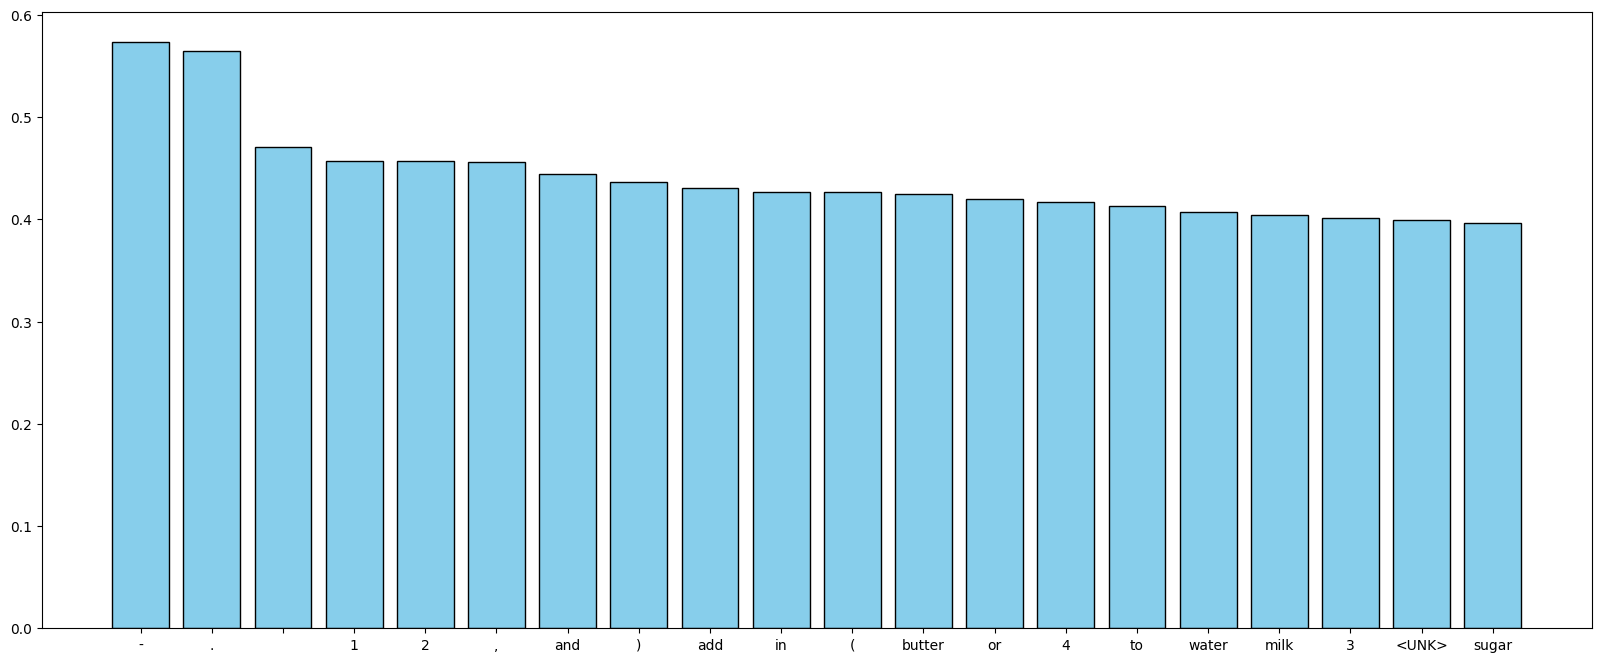

In [16]:
plot_dict(vectorizer.rate_words(average_crv * 0.0001178967224711153, mode = 'sqrt'))